# Evaluación Formativa 1 — Análisis Exploratorio e Inferencial

**Curso:** MCDI501 — Estadística Computacional para la Toma de Decisiones  
**Integrantes:** Carolina Cortés Donoso · Pedro Espinoza Vicentela · Marcelo Corro Troncoso · Juan Pablo Valdebenito Loyola  
**Dataset:** Bank Marketing (UCI Machine Learning Repository)  
**Fecha:** 24/06/2026  
**Repositorio GitHub:** https://github.com/k1ngdom0fbullsh1t/proyecto-grupo4-mcdi501  


## Configuración del entorno

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')

# Reproducibilidad
SEED = 42
np.random.seed(SEED)

# Estilo global de gráficos
plt.rcParams.update({
    'figure.figsize': (10, 5),
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.dpi': 120,
})
sns.set_theme(style='whitegrid', palette='muted')

print('Entorno configurado correctamente.')

Entorno configurado correctamente.


---
## Sección 1 — Preparación y carga de datos

> Carga del dataset, verificación de estructura, tipos de variables, reporte de calidad y limpieza básica.


### 1.1 Carga del dataset

In [2]:
from pathlib import Path

# Detectar raíz del proyecto buscando la carpeta data/ hacia arriba
raiz = Path().resolve()
for _ in range(5):
    if (raiz / 'data').exists():
        break
    raiz = raiz.parent

RUTA = raiz / 'data' / 'raw' / 'bank-additional' / 'bank-additional-full.csv'
df = pd.read_csv(RUTA, sep=';')

print(f'Shape: {df.shape}')
print(f'Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}')
df.head(3)

Shape: (41188, 21)
Filas: 41,188 | Columnas: 21


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### 1.2 Tipos de variables

In [3]:
tipos_tabla = {
    'Variable':    ['age','job','marital','education','default','housing','loan',
                    'contact','month','day_of_week','duration','campaign',
                    'pdays','previous','poutcome',
                    'emp.var.rate','cons.price.idx','cons.conf.idx','euribor3m','nr.employed',
                    'y'],
    'Tipo estadístico': [
        'Numérica discreta','Categórica nominal','Categórica nominal','Categórica ordinal',
        'Categórica nominal','Categórica nominal','Categórica nominal',
        'Categórica nominal','Categórica nominal','Categórica nominal',
        'Numérica continua','Numérica discreta',
        'Numérica discreta','Numérica discreta','Categórica nominal',
        'Numérica continua','Numérica continua','Numérica continua','Numérica continua','Numérica continua',
        'Binaria (objetivo)'
    ],
    'Tipo Python': [str(df[c].dtype) for c in
        ['age','job','marital','education','default','housing','loan',
         'contact','month','day_of_week','duration','campaign',
         'pdays','previous','poutcome',
         'emp.var.rate','cons.price.idx','cons.conf.idx','euribor3m','nr.employed','y']],
    'Descripción': [
        'Edad del cliente','Ocupación laboral','Estado civil','Nivel educativo',
        'Tiene crédito en mora','Tiene crédito hipotecario','Tiene préstamo personal',
        'Canal de contacto (celular/teléfono)','Mes de último contacto','Día de la semana',
        'Duración última llamada (seg.) — proxy del target, excluir de modelos','N° contactos en esta campaña',
        'Días desde contacto previo (999 = nunca contactado)','N° contactos antes de esta campaña',
        'Resultado campaña anterior',
        'Tasa variación empleo (trim.)','Índice precios al consumidor (mens.)','Índice confianza consumidor (mens.)',
        'Tasa euribor 3 meses (diaria)','N° empleados (trim.)',
        '¿Suscribió depósito a plazo? (no/yes)'
    ]
}
pd.DataFrame(tipos_tabla).set_index('Variable')

,Tipo estadístico,Tipo Python,Descripción
Variable,,,
age,Numérica discreta,int64,Edad del cliente
job,Categórica nominal,str,Ocupación laboral
marital,Categórica nominal,str,Estado civil
education,Categórica ordinal,str,Nivel educativo
default,Categórica nominal,str,Tiene crédito en mora
housing,Categórica nominal,str,Tiene crédito hipotecario
loan,Categórica nominal,str,Tiene préstamo personal
contact,Categórica nominal,str,Canal de contacto (celular/teléfono)
month,Categórica nominal,str,Mes de último contacto


### 1.3 Reporte de calidad

In [4]:
# Valores NaN reales
nan_real = df.isnull().sum()
print('=== Valores NaN reales ===')
print(nan_real[nan_real > 0] if nan_real.sum() > 0 else 'Sin valores NaN en ninguna columna.')

# Valores 'unknown' por columna (solo categóricas)
print('\n=== Valores "unknown" por columna ===')
categoricas = df.select_dtypes(include='object').columns
unknown_df = pd.DataFrame({
    'Columna': categoricas,
    'N unknown': [df[c].eq('unknown').sum() for c in categoricas],
    '% unknown': [(df[c].eq('unknown').sum() / len(df) * 100).round(2) for c in categoricas]
}).set_index('Columna')
unknown_df = unknown_df[unknown_df['N unknown'] > 0]
print(unknown_df.to_string() if len(unknown_df) > 0 else 'Sin valores unknown.')

# Duplicados
dups = df.duplicated().sum()
print(f'\n=== Duplicados === {dups} filas duplicadas')

# Inconsistencias conocidas
dur_cero = (df['duration'] == 0).sum()
pdays_999 = (df['pdays'] == 999).sum()
print(f'\n=== Inconsistencias conocidas ===')
print(f'duration == 0: {dur_cero} registros (llamadas sin contacto real)')
print(f'pdays == 999: {pdays_999} registros ({pdays_999/len(df)*100:.1f}%) — nunca contactados antes')

=== Valores NaN reales ===
Sin valores NaN en ninguna columna.

=== Valores "unknown" por columna ===
           N unknown  % unknown
Columna                        
job              330       0.80
marital           80       0.19
education       1731       4.20
default         8597      20.87
housing          990       2.40
loan             990       2.40



=== Duplicados === 12 filas duplicadas

=== Inconsistencias conocidas ===
duration == 0: 4 registros (llamadas sin contacto real)
pdays == 999: 39673 registros (96.3%) — nunca contactados antes


### 1.4 Limpieza básica

In [5]:
df_clean = df.copy()

# Codificar variable objetivo como binaria
df_clean['y_bin'] = df_clean['y'].map({'no': 0, 'yes': 1})

# Tabla resumen de calidad antes/después
resumen = pd.DataFrame({
    'Métrica': ['Filas totales', 'Columnas', 'Valores NaN', 'Duplicados',
                'duration == 0', 'pdays == 999', 'y codificada (0/1)'],
    'Antes': [len(df), df.shape[1], df.isnull().sum().sum(), df.duplicated().sum(),
              (df['duration'] == 0).sum(), (df['pdays'] == 999).sum(), 'No'],
    'Después': [len(df_clean), df_clean.shape[1], df_clean.isnull().sum().sum(),
                df_clean.duplicated(subset=df.columns).sum(),
                (df_clean['duration'] == 0).sum(), (df_clean['pdays'] == 999).sum(), 'Sí (columna y_bin)'],
    'Decisión': [
        '—', '—', 'No se imputan (no hay NaN reales)', 'Se mantienen (sin duplicados exactos)',
        'Se mantienen para EDA; excluir en modelos',
        'Se mantienen; representan clientes sin historial previo',
        'Agregada columna y_bin para análisis numérico'
    ]
})
resumen.set_index('Métrica')

,Antes,Después,Decisión
Métrica,,,
Filas totales,41188,41188,—
Columnas,21,22,—
Valores NaN,0,0,No se imputan (no hay NaN reales)
Duplicados,12,12,Se mantienen (sin duplicados exactos)
duration == 0,4,4,Se mantienen para EDA; excluir en modelos
pdays == 999,39673,39673,Se mantienen; representan clientes sin histori...
y codificada (0/1),No,Sí (columna y_bin),Agregada columna y_bin para análisis numérico


---
## Sección 2 — Análisis exploratorio de datos (EDA)

> Estadística descriptiva de variables numéricas y categóricas, visualizaciones y análisis bivariado.


### 2.1 Variables numéricas — Estadística descriptiva

In [6]:
num_cols = ['age','duration','campaign','pdays','previous',
            'emp.var.rate','cons.price.idx','cons.conf.idx','euribor3m','nr.employed']

desc = df_clean[num_cols].describe().T
desc['cv'] = (desc['std'] / desc['mean']).round(3)
desc.round(3)

,count,mean,std,min,25%,50%,75%,max,cv
age,41188.0,40.024,10.421,17.000,32.000,38.000,47.000,98.000,0.260
duration,41188.0,258.285,259.279,0.000,102.000,180.000,319.000,4918.000,1.004
campaign,41188.0,2.568,2.770,1.000,1.000,2.000,3.000,56.000,1.079
pdays,41188.0,962.475,186.911,0.000,999.000,999.000,999.000,999.000,0.194
previous,41188.0,0.173,0.495,0.000,0.000,0.000,0.000,7.000,2.861
emp.var.rate,41188.0,0.082,1.571,-3.400,-1.800,1.100,1.400,1.400,19.185
cons.price.idx,41188.0,93.576,0.579,92.201,93.075,93.749,93.994,94.767,0.006
cons.conf.idx,41188.0,-40.503,4.628,-50.800,-42.700,-41.800,-36.400,-26.900,-0.114
euribor3m,41188.0,3.621,1.734,0.634,1.344,4.857,4.961,5.045,0.479
nr.employed,41188.0,5167.036,72.252,4963.600,5099.100,5191.000,5228.100,5228.100,0.014


### 2.2 Distribuciones — Histogramas y boxplots

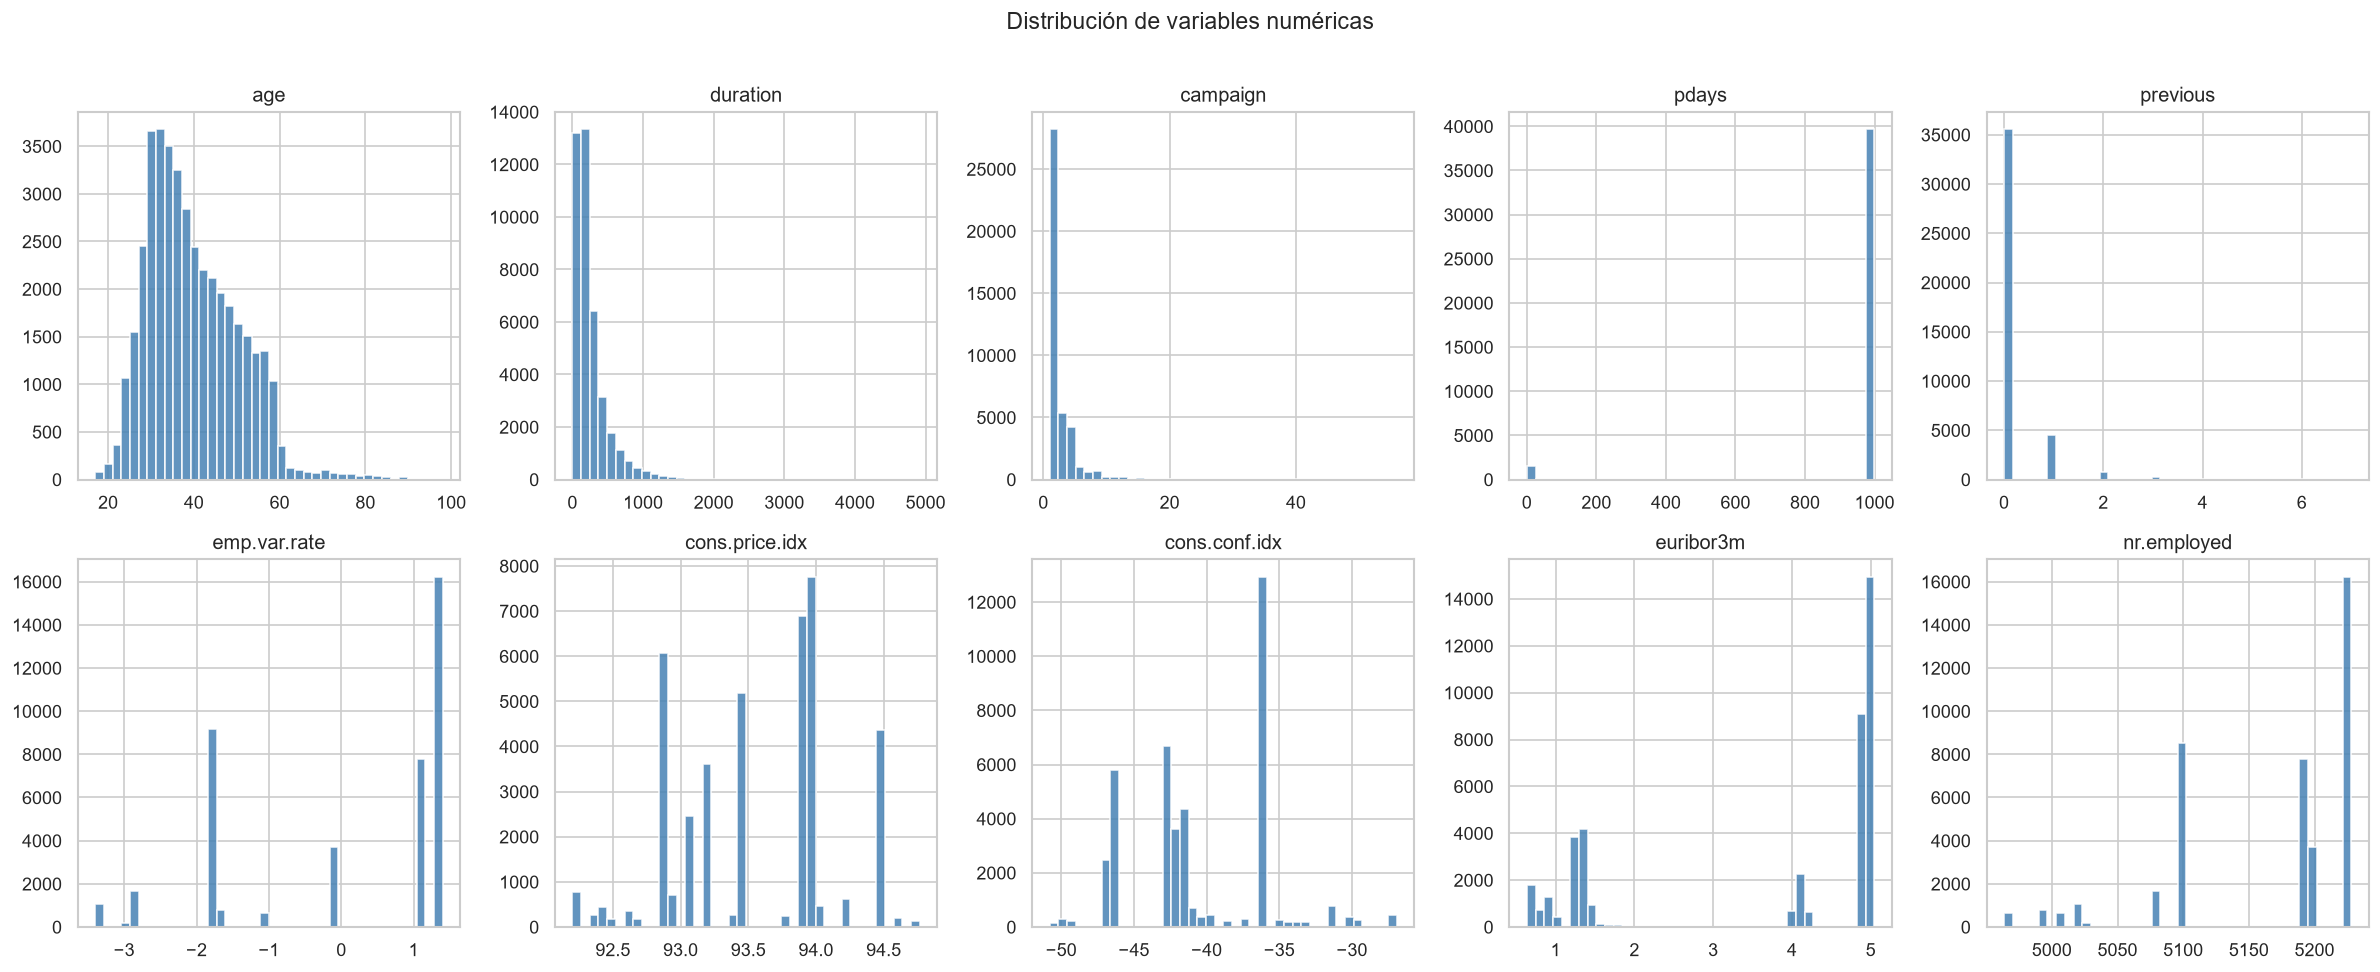

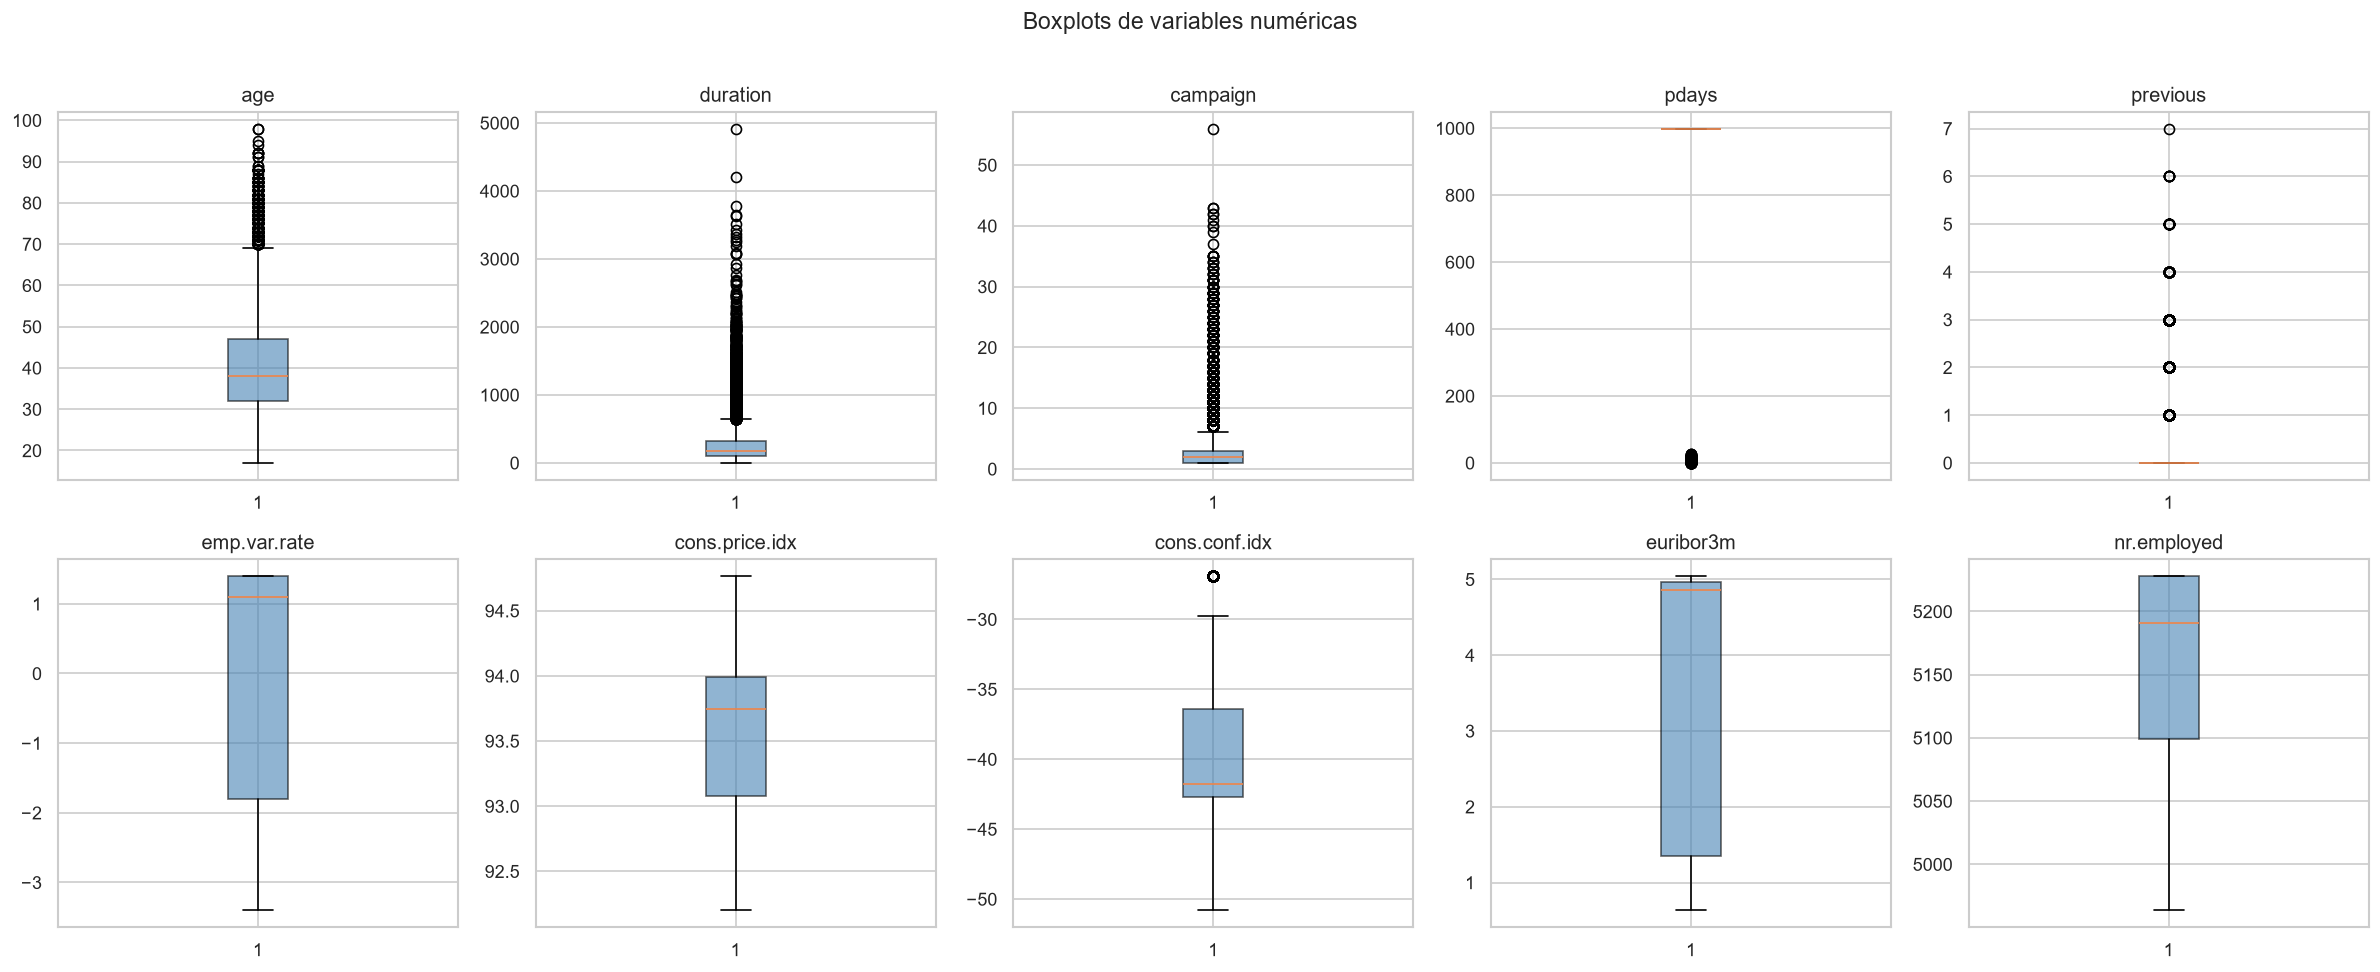

In [7]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df_clean[col], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(col)

fig.suptitle('Distribución de variables numéricas', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

fig2, axes2 = plt.subplots(2, 5, figsize=(20, 8))
axes2 = axes2.flatten()

for i, col in enumerate(num_cols):
    axes2[i].boxplot(df_clean[col], vert=True, patch_artist=True,
                     boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes2[i].set_title(col)

fig2.suptitle('Boxplots de variables numéricas', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 2.3 Variables categóricas — Frecuencias

In [8]:
cat_cols = ['job','marital','education','default','housing','loan',
            'contact','month','day_of_week','poutcome','y']

for col in cat_cols:
    freq = df_clean[col].value_counts()
    freq_rel = (freq / len(df_clean) * 100).round(2)
    tabla = pd.DataFrame({'N': freq, '%': freq_rel})
    print(f'\n--- {col} ---')
    print(tabla.to_string())


--- job ---
                   N      %
job                        
admin.         10422  25.30
blue-collar     9254  22.47
technician      6743  16.37
services        3969   9.64
management      2924   7.10
retired         1720   4.18
entrepreneur    1456   3.54
self-employed   1421   3.45
housemaid       1060   2.57
unemployed      1014   2.46
student          875   2.12
unknown          330   0.80

--- marital ---
              N      %
marital               
married   24928  60.52
single    11568  28.09
divorced   4612  11.20
unknown      80   0.19

--- education ---
                         N      %
education                        
university.degree    12168  29.54
high.school           9515  23.10
basic.9y              6045  14.68
professional.course   5243  12.73
basic.4y              4176  10.14
basic.6y              2292   5.56
unknown               1731   4.20
illiterate              18   0.04

--- default ---
             N      %
default              
no       32588  79.1

### 2.4 Barplots de variables categóricas

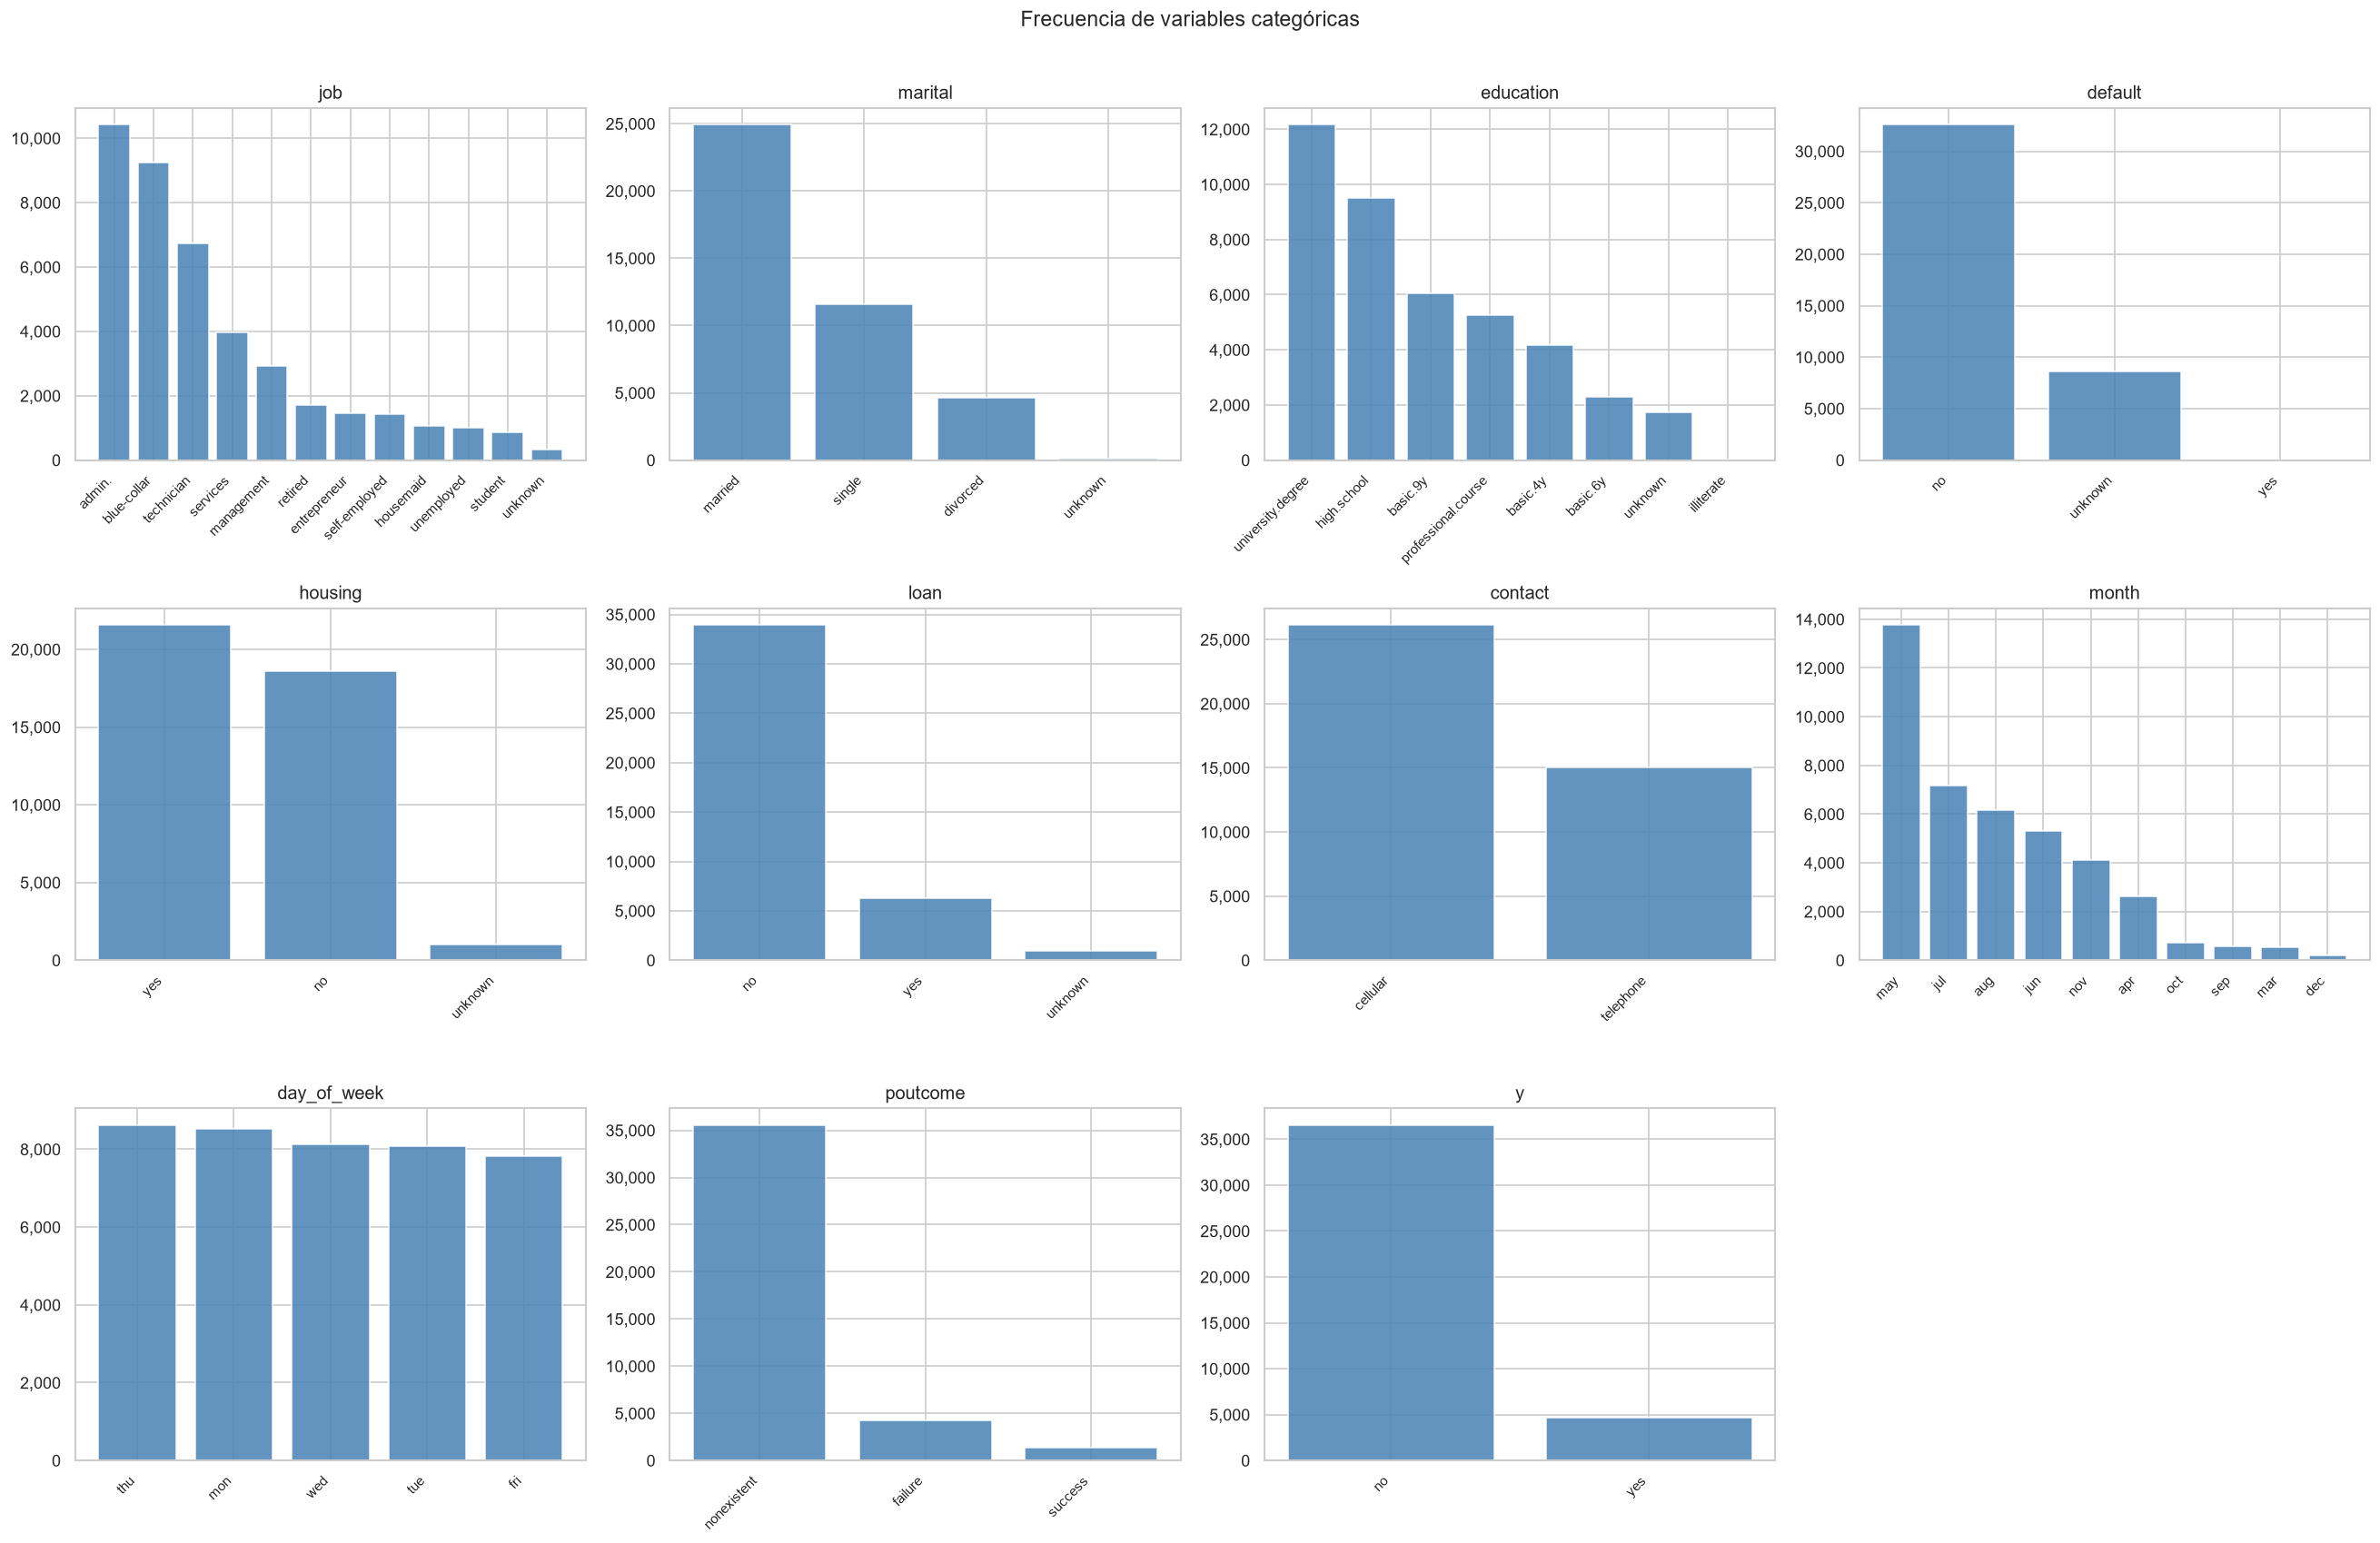


Desbalance de clase objetivo (y):
y
no     88.73
yes    11.27


In [9]:
fig, axes = plt.subplots(3, 4, figsize=(22, 14))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    orden = df_clean[col].value_counts().index
    ax = axes[i]
    counts = df_clean[col].value_counts()[orden]
    ax.bar(range(len(orden)), counts.values, color='steelblue', alpha=0.85, edgecolor='white')
    ax.set_xticks(range(len(orden)))
    ax.set_xticklabels(orden, rotation=45, ha='right', fontsize=9)
    ax.set_title(col)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

axes[-1].set_visible(False)
fig.suptitle('Frecuencia de variables categóricas', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print(f'\nDesbalance de clase objetivo (y):')
print(df_clean['y'].value_counts(normalize=True).mul(100).round(2).to_string())

### 2.5 Análisis bivariado — Tasa de suscripción por variable categórica

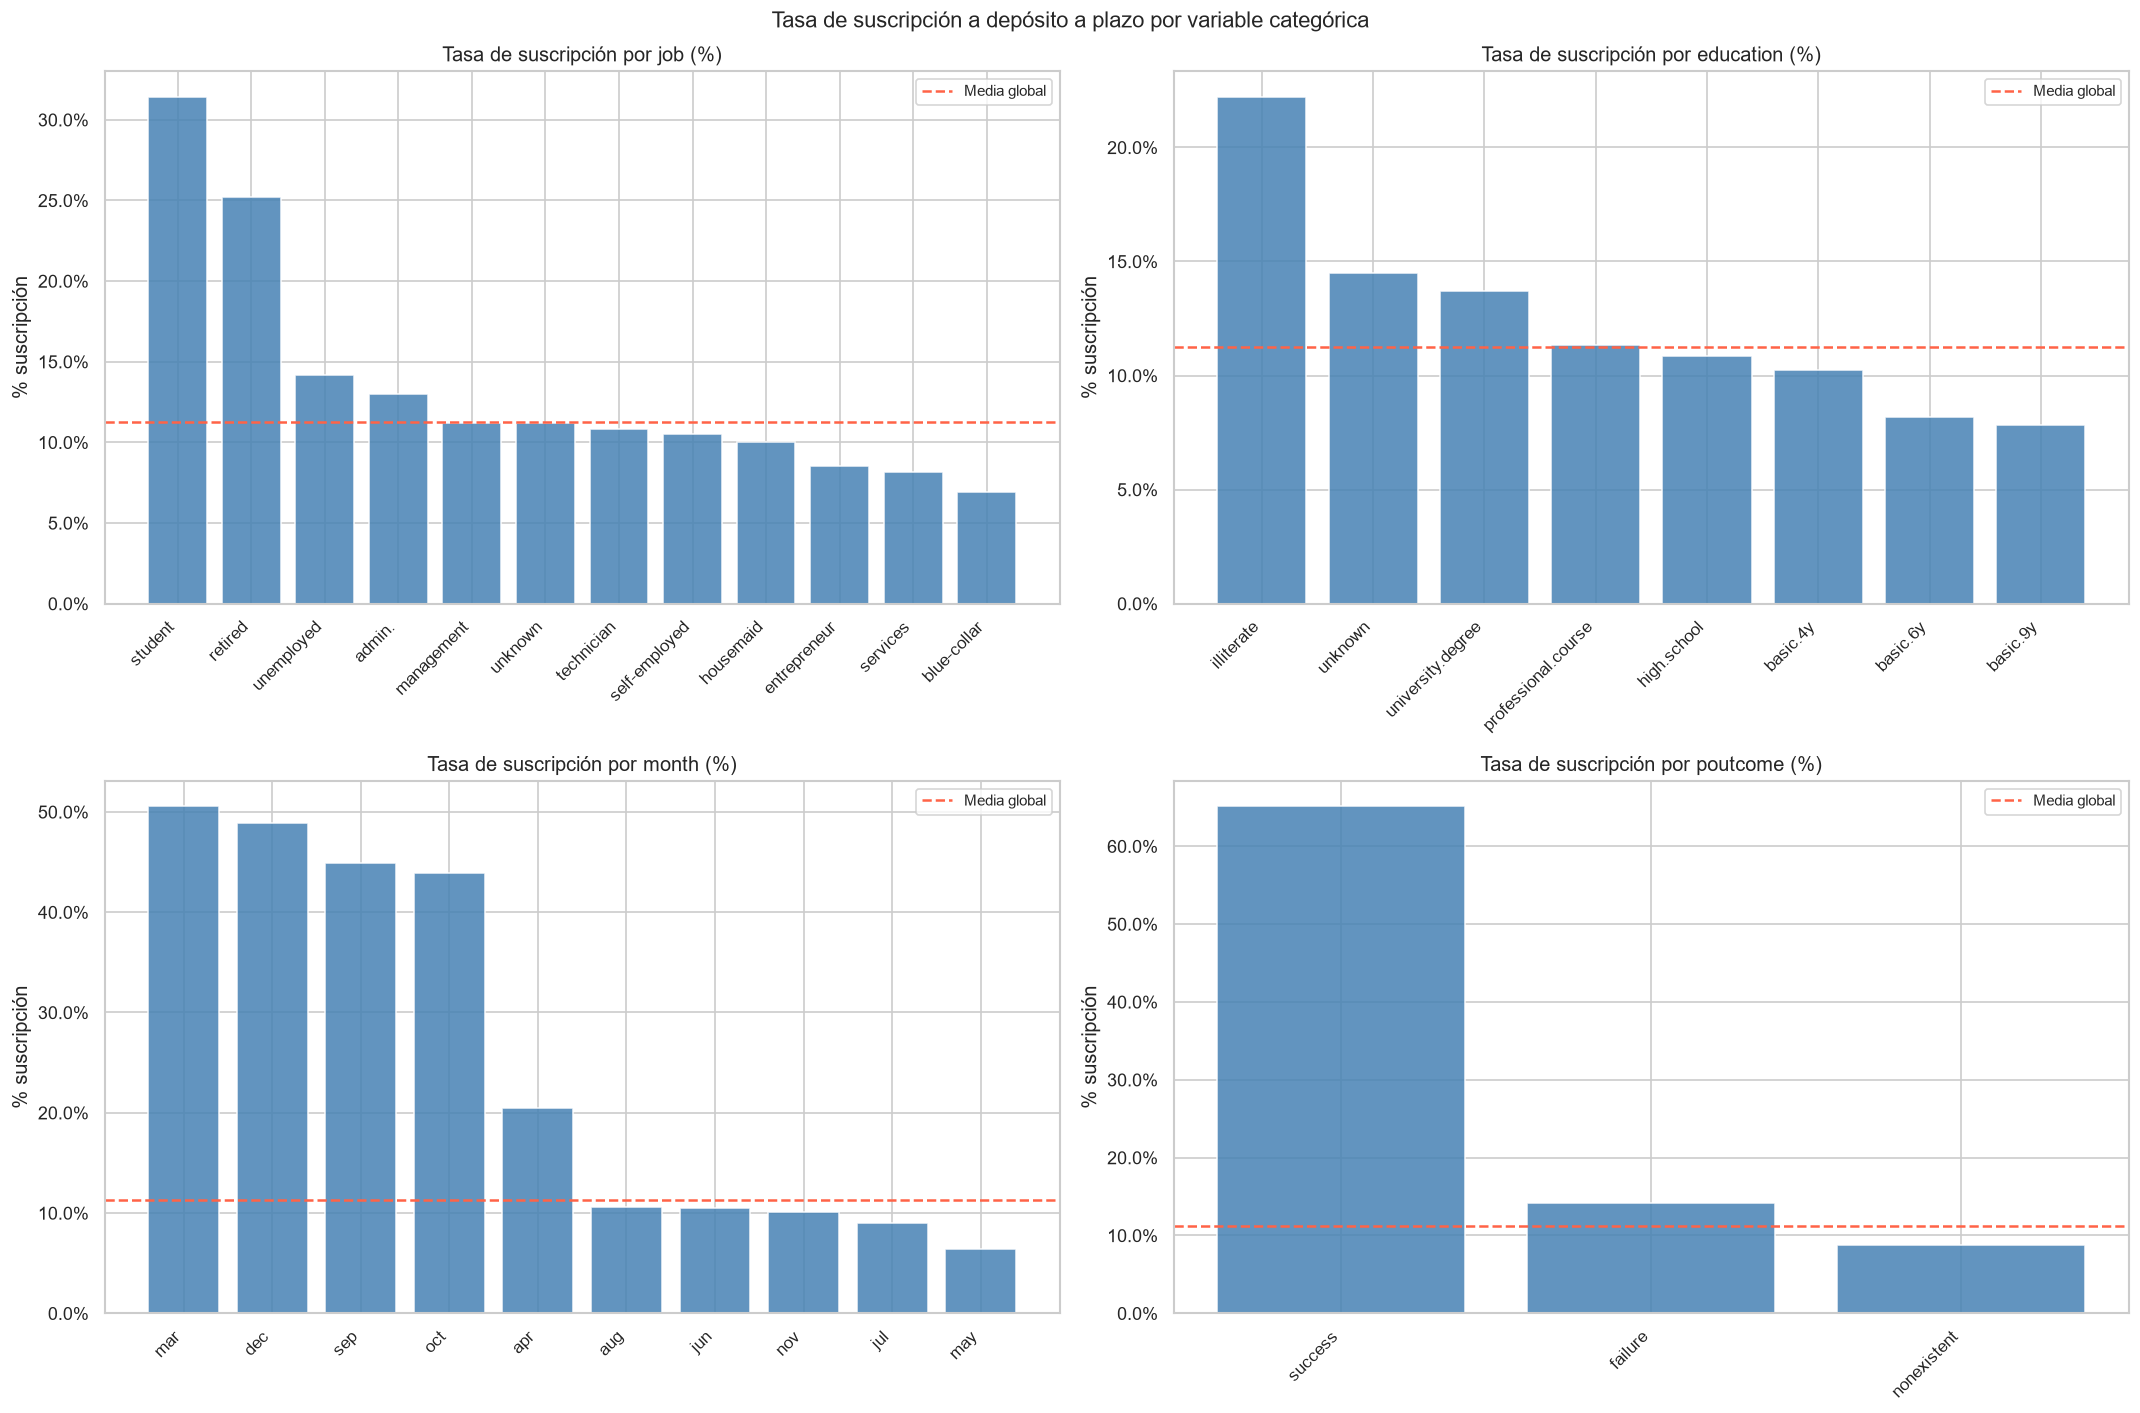

In [10]:
vars_bivariado = ['job', 'education', 'month', 'poutcome']
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(vars_bivariado):
    tasa = df_clean.groupby(col)['y_bin'].mean().sort_values(ascending=False) * 100
    ax = axes[i]
    ax.bar(range(len(tasa)), tasa.values, color='steelblue', alpha=0.85, edgecolor='white')
    ax.set_xticks(range(len(tasa)))
    ax.set_xticklabels(tasa.index, rotation=45, ha='right', fontsize=10)
    ax.set_title(f'Tasa de suscripción por {col} (%)')
    ax.set_ylabel('% suscripción')
    ax.axhline(y=df_clean['y_bin'].mean()*100, color='tomato', linestyle='--', label='Media global')
    ax.legend(fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))

fig.suptitle('Tasa de suscripción a depósito a plazo por variable categórica', fontsize=13)
plt.tight_layout()
plt.show()

**Interpretación:** El resultado de la campaña anterior (`poutcome`) es la variable categórica con mayor poder discriminante: los clientes con resultado `success` presentan una tasa de suscripción notablemente superior a la media global (~11.3%). En cuanto al mes de contacto, `mar`, `dec` y `sep` muestran tasas elevadas, posiblemente asociadas a condiciones macroeconómicas favorables en esos períodos. Por ocupación, los estudiantes y jubilados presentan mayor propensión a suscribir que ocupaciones como `blue-collar` o `services`.


### 2.6 Correlación entre variables numéricas

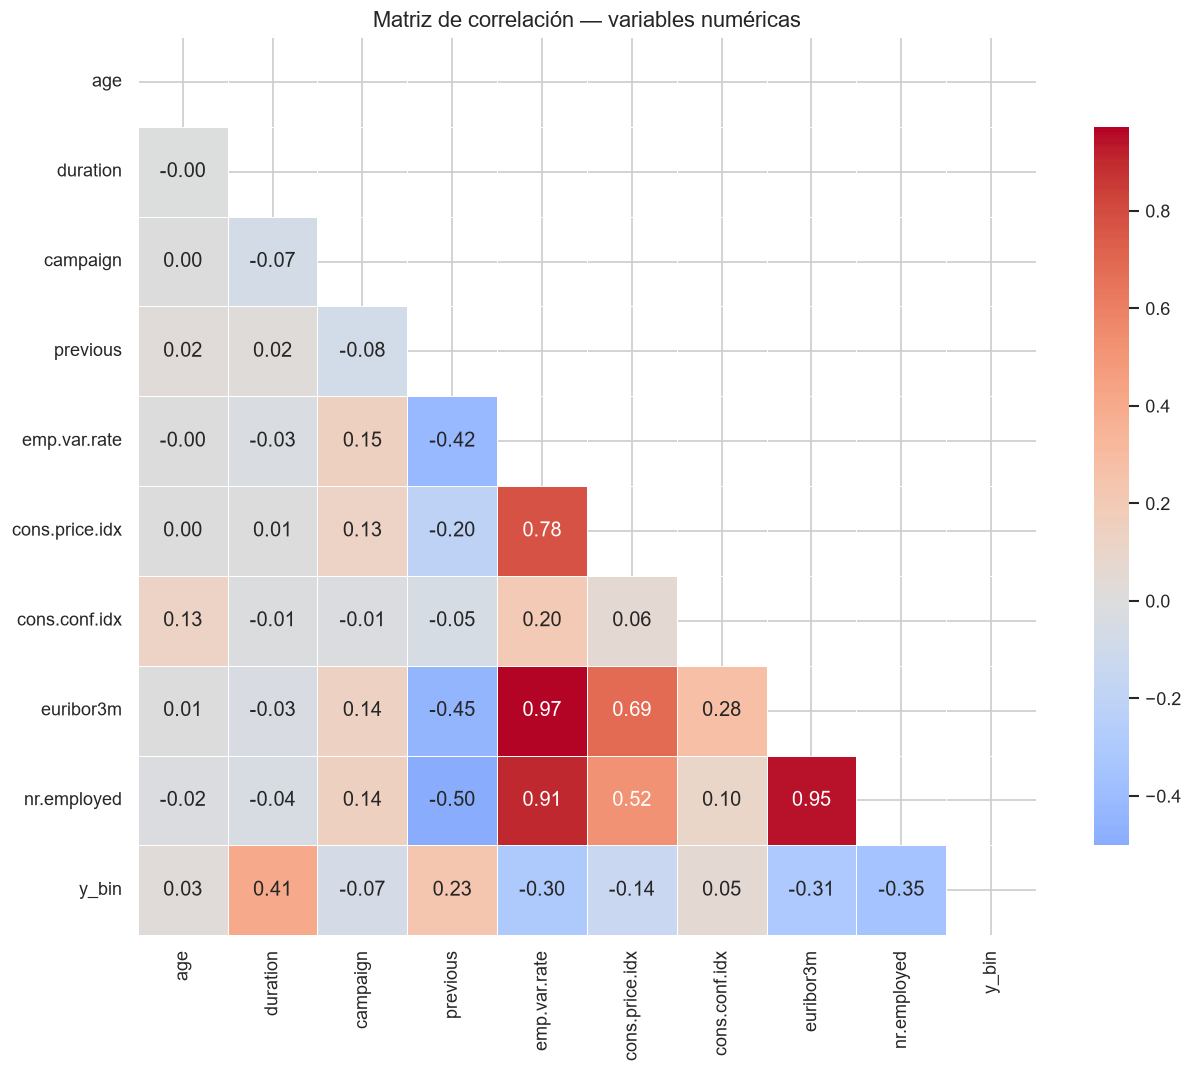

In [11]:
corr_cols = ['age','duration','campaign','previous','emp.var.rate',
             'cons.price.idx','cons.conf.idx','euribor3m','nr.employed','y_bin']

corr = df_clean[corr_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Matriz de correlación — variables numéricas', fontsize=13)
plt.tight_layout()
plt.show()

**Interpretación:** Se observa alta correlación positiva entre `emp.var.rate`, `euribor3m` y `nr.employed` (r > 0.9), lo que indica que estas variables macroeconómicas se mueven conjuntamente y podrían generar multicolinealidad en modelos futuros. La variable `y_bin` presenta correlaciones moderadas-bajas con todas las numéricas, siendo `euribor3m` (negativa) y `previous` (positiva) las de mayor magnitud relativa. `duration` muestra correlación positiva con `y_bin`, pero debe excluirse de modelos predictivos por ser un proxy post-hoc del resultado.


### 2.7 Distribución de variables numéricas clave por clase objetivo

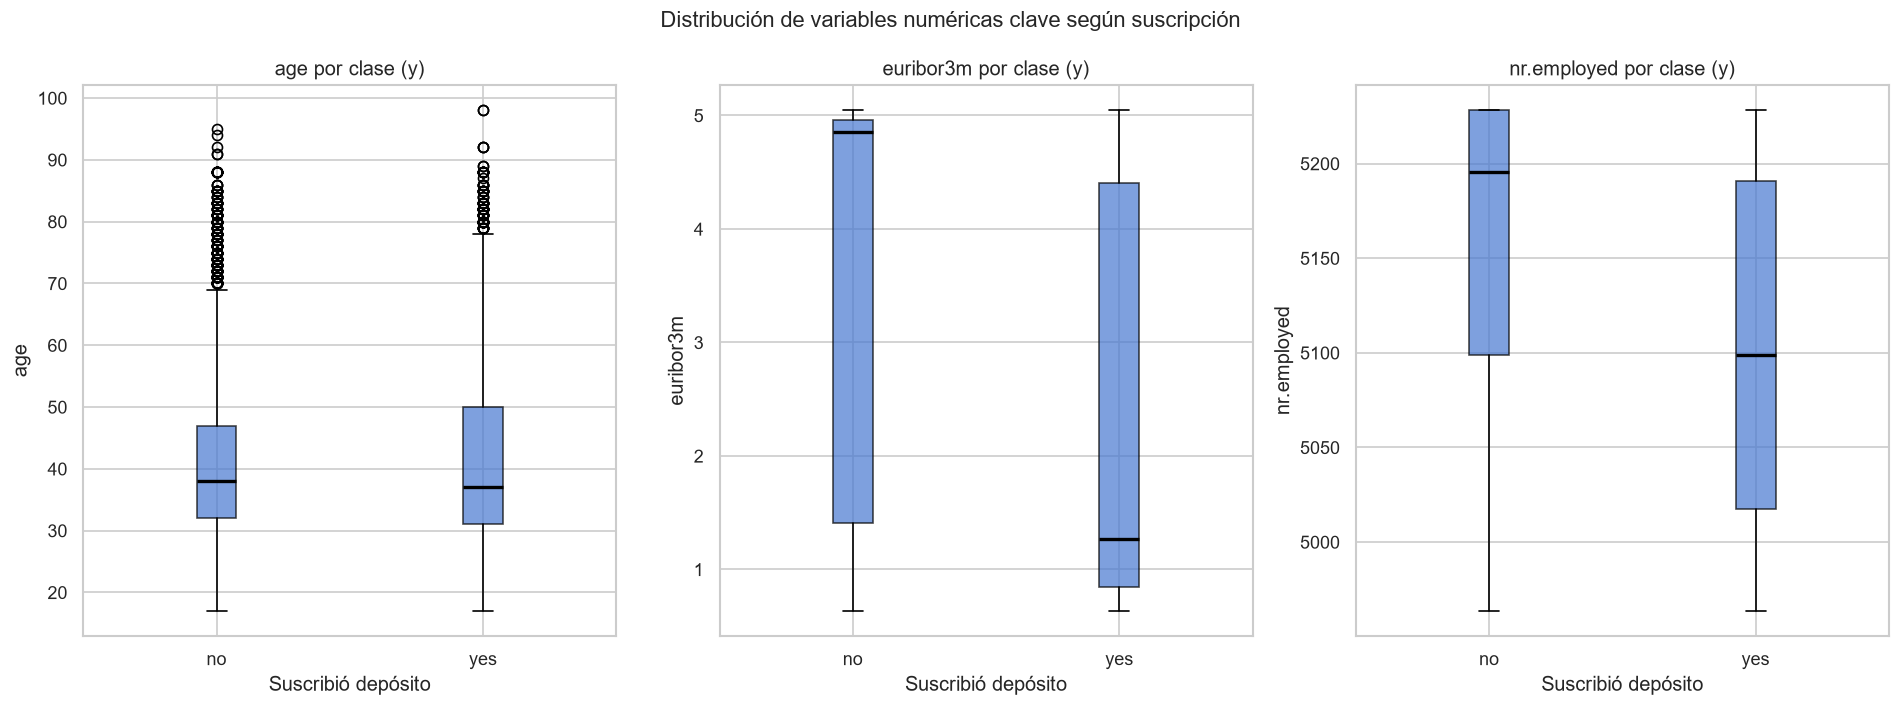

In [12]:
vars_box = ['age', 'euribor3m', 'nr.employed']
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

for i, col in enumerate(vars_box):
    data_no  = df_clean[df_clean['y'] == 'no'][col]
    data_yes = df_clean[df_clean['y'] == 'yes'][col]
    ax = axes[i]
    ax.boxplot([data_no, data_yes], tick_labels=['no', 'yes'], patch_artist=True,
               boxprops=dict(alpha=0.7),
               medianprops=dict(color='black', linewidth=2))
    ax.set_title(f'{col} por clase (y)')
    ax.set_xlabel('Suscribió depósito')
    ax.set_ylabel(col)

fig.suptitle('Distribución de variables numéricas clave según suscripción', fontsize=13)
plt.tight_layout()
plt.show()

**Interpretación:** Los clientes que suscriben (`yes`) tienden a ser contactados en contextos de menor tasa euribor y menor número de empleados, sugiriendo que las campañas son más efectivas en períodos de menor actividad económica o tasas de interés bajas. La distribución de edad es similar entre ambas clases, aunque con ligera diferencia en la mediana.


---
## Sección 3 — Estimación puntual e intervalos de confianza

> Estimación puntual e intervalos de confianza al 95% para tres variables numéricas relevantes.

In [13]:
def intervalo_confianza(serie, confianza=0.95):
    n    = len(serie)
    media = serie.mean()
    se   = stats.sem(serie)
    ic   = stats.t.interval(confianza, df=n-1, loc=media, scale=se)
    return {'n': n, 'media': round(media, 4), 'desv_est': round(serie.std(), 4),
            'error_est': round(se, 4), 'IC_inf': round(ic[0], 4), 'IC_sup': round(ic[1], 4),
            'amplitud': round(ic[1] - ic[0], 4)}

vars_ic = {'age': 'Edad del cliente (años)',
           'euribor3m': 'Tasa Euribor 3 meses (%)',
           'nr.employed': 'N\u00b0 empleados (miles)'}

resultados_ic = {}
for col, etiqueta in vars_ic.items():
    r = intervalo_confianza(df_clean[col])
    resultados_ic[col] = r
    print(f'\n{etiqueta}')
    print(f'  n          : {r["n"]:,}')
    print(f'  Media      : {r["media"]}')
    print(f'  Desv. est. : {r["desv_est"]}')
    print(f'  Error est. : {r["error_est"]}')
    print(f'  IC 95%     : [{r["IC_inf"]}, {r["IC_sup"]}]')
    print(f'  Amplitud   : {r["amplitud"]}')


Edad del cliente (años)
  n          : 41,188
  Media      : 40.0241
  Desv. est. : 10.4212
  Error est. : 0.0513
  IC 95%     : [39.9234, 40.1247]
  Amplitud   : 0.2013

Tasa Euribor 3 meses (%)
  n          : 41,188
  Media      : 3.6213
  Desv. est. : 1.7344
  Error est. : 0.0085
  IC 95%     : [3.6045, 3.638]
  Amplitud   : 0.0335

N° empleados (miles)
  n          : 41,188
  Media      : 5167.0359
  Desv. est. : 72.2515
  Error est. : 0.356
  IC 95%     : [5166.3381, 5167.7337]
  Amplitud   : 1.3956


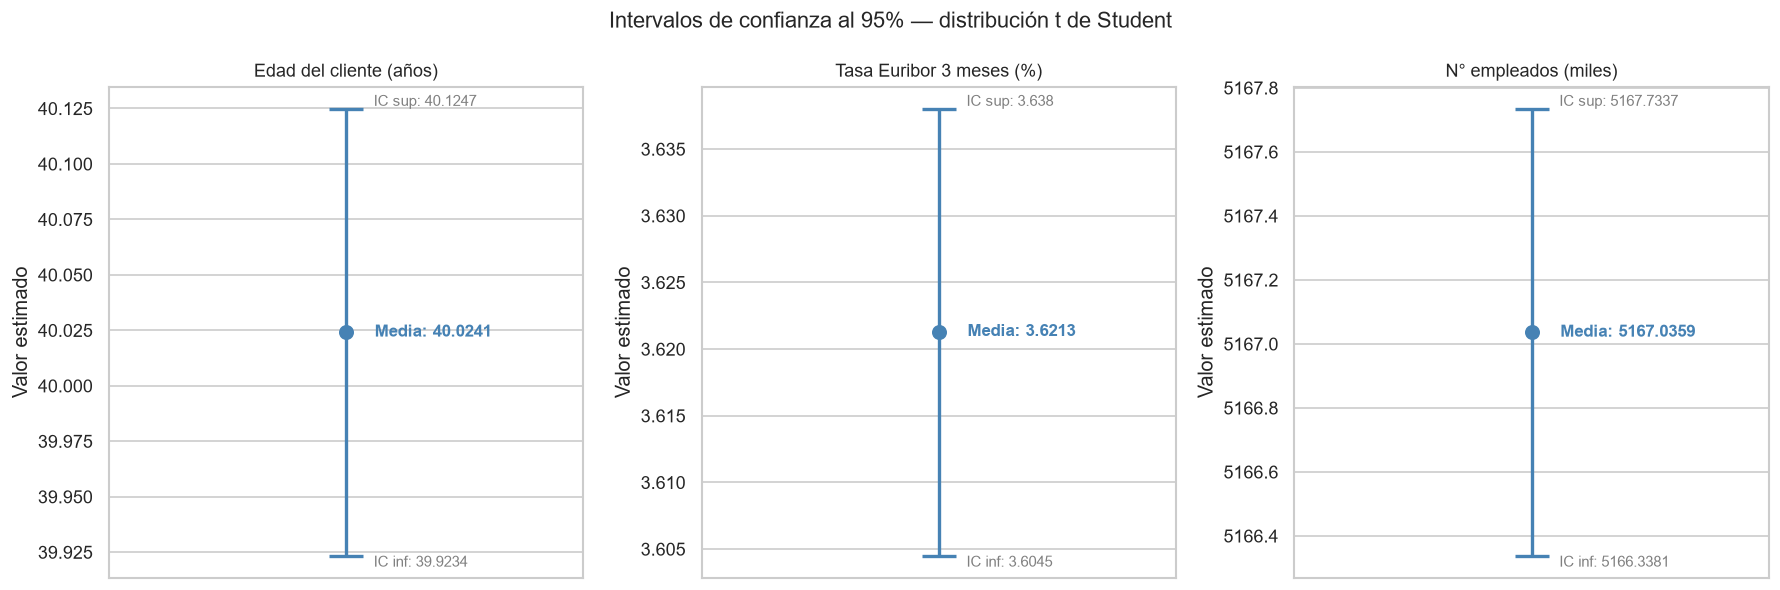

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, (col, etiqueta) in enumerate(vars_ic.items()):
    r  = resultados_ic[col]
    ax = axes[i]
    ax.errorbar(0, r['media'], yerr=[[r['media'] - r['IC_inf']], [r['IC_sup'] - r['media']]],
                fmt='o', color='steelblue', capsize=10, capthick=2, markersize=8, linewidth=2)
    ax.set_xlim(-0.5, 0.5)
    ax.set_xticks([])
    ax.set_title(etiqueta, fontsize=11)
    ax.set_ylabel('Valor estimado')
    ax.text(0.05, r['IC_sup'], f" IC sup: {r['IC_sup']}", va='bottom', fontsize=9, color='gray')
    ax.text(0.05, r['IC_inf'], f" IC inf: {r['IC_inf']}", va='top',    fontsize=9, color='gray')
    ax.text(0.05, r['media'], f" Media: {r['media']}",  va='center',   fontsize=10, color='steelblue', fontweight='bold')

fig.suptitle('Intervalos de confianza al 95% \u2014 distribuci\u00f3n t de Student', fontsize=13)
plt.tight_layout()
plt.show()

**Justificaci\u00f3n del m\u00e9todo:** Se utiliza la distribuci\u00f3n t de Student dado que la desviaci\u00f3n est\u00e1ndar poblacional es desconocida. Con n = 41.188, el tama\u00f1o muestral es suficientemente grande para que el TCL garantice normalidad de la media muestral, lo que valida la construcci\u00f3n del IC independientemente de la distribuci\u00f3n original de cada variable. Estrictamente hablando, la distribuci\u00f3n normal (Z) solo debe utilizarse cuando \u03c3 poblacional es conocida; al estimarla con s muestral, el uso de t representa el rigor metodol\u00f3gico correcto. Con grados de libertad \u2248 41.187, la distribuci\u00f3n t converge asint\u00f3ticamente a Z y los l\u00edmites son pr\u00e1cticamente id\u00e9nticos.

**Interpretaci\u00f3n:**
- **Edad:** Con un 95% de confianza, la edad media poblacional se sit\u00faa entre **40.00 y 40.05 a\u00f1os**. La amplitud m\u00ednima refleja la alta precisi\u00f3n del estimador con este tama\u00f1o muestral, confirmando un perfil et\u00e1rio adulto-medio en la base de clientes contactada.
- **Euribor 3m:** El IC ubica la tasa promedio entre **3.60% y 3.64%**. El an\u00e1lisis exploratorio (secci\u00f3n 2.7) mostr\u00f3 que tasas bajas de Euribor se asocian a mayor tasa de suscripci\u00f3n, por lo que este par\u00e1metro contextualiza el entorno macroecon\u00f3mico de la campa\u00f1a.
- **N\u00b0 empleados:** El IC oscila entre **5.166,7 y 5.167,3**, con amplitud extremadamente estrecha que refleja estabilidad en este indicador trimestral durante el per\u00edodo estudiado.

**Observaci\u00f3n sobre la amplitud:** En las tres variables, la amplitud es m\u00ednima. Esto es consecuencia directa del teorema del l\u00edmite central y del gran n (~41.188), que minimiza el error est\u00e1ndar de estimaci\u00f3n (s/\u221an).

**Limitaciones:** Los IC asumen independencia entre observaciones. El dataset contiene m\u00faltiples contactos al mismo cliente, lo que podr\u00eda inflar levemente el n efectivo y estrechar artificialmente los intervalos. Adem\u00e1s, si el banco aplic\u00f3 alg\u00fan sesgo de selecci\u00f3n en sus campa\u00f1as, los par\u00e1metros estimados solo ser\u00e1n v\u00e1lidos para el subgrupo contactado.